Train the model with 3 different ML Models


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

Information about the financial_regression.csv dataset

In [2]:
# Load the full dataset
df = pd.read_csv('data/raw/financial_regression.csv')

print(f"Full dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:10]}...")  # Show first 10

Full dataset shape: (3904, 47)
Columns: ['date', 'sp500 open', 'sp500 high', 'sp500 low', 'sp500 close', 'sp500 volume', 'sp500 high-low', 'nasdaq open', 'nasdaq high', 'nasdaq low']...


Only Data related to GOLD

In [3]:
# Select only gold-related columns
gold_columns = ['date', 'gold open', 'gold high', 'gold low', 'gold close', 'gold volume']

df_gold = df[gold_columns].copy()

# Rename to standard OHLCV format (easier to work with)
df_gold.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

# Convert date to datetime
df_gold['Date'] = pd.to_datetime(df_gold['Date'])

# Sort by date
df_gold = df_gold.sort_values('Date').reset_index(drop=True)

print(f"Gold-only dataset shape: {df_gold.shape}")
print(df_gold.head())

Gold-only dataset shape: (3904, 6)
        Date    Open    High     Low   Close      Volume
0 2010-01-14  111.51  112.37  110.79  112.03  18305238.0
1 2010-01-15  111.35  112.01  110.38  110.86  18000724.0
2 2010-01-18     NaN     NaN     NaN     NaN         NaN
3 2010-01-19  110.95  111.75  110.83  111.52  10467927.0
4 2010-01-20  109.97  110.05  108.46  108.94  17534231.0


GOLD DATA SUMMARY

In [4]:
print("\n=== GOLD DATA SUMMARY ===")
print(f"Date range: {df_gold['Date'].min()} to {df_gold['Date'].max()}")
print(f"Total rows: {len(df_gold):,}")
print(f"\nMissing values:\n{df_gold.isnull().sum()}")
print(f"\nGold price range: ${df_gold['Close'].min():.2f} to ${df_gold['Close'].max():.2f}")
# print("Indian Price : \n")
# print(f"\nGold price range: ${(df_gold['Close'].min())*93:.2f} to ${(df_gold['Close'].max())*93:.2f}")


=== GOLD DATA SUMMARY ===
Date range: 2010-01-14 00:00:00 to 2024-10-23 00:00:00
Total rows: 3,904

Missing values:
Date        0
Open      185
High      185
Low       185
Close     185
Volume    185
dtype: int64

Gold price range: $100.50 to $253.93


In [5]:
# # Save for later use
# df_gold.to_csv('data/processed/gold_baseline_clean.csv', index=False)
# print("Saved clean gold data")

In [6]:
print("\n=== DATA QUALITY CHECK ===")

# 1. Check for missing values
missing = df_gold.isnull().sum()
print(f"\n1. Missing values:\n{missing}")

# 2. Check for duplicates
duplicates = df_gold.duplicated(subset=['Date']).sum()
print(f"\n2. Duplicate dates: {duplicates}")

# 3. Validate OHLC logic
invalid_high_low = df_gold[df_gold['High'] < df_gold['Low']]
print(f"\n3. Invalid High < Low: {len(invalid_high_low)} rows")

invalid_high = df_gold[(df_gold['High'] < df_gold['Open']) | 
                        (df_gold['High'] < df_gold['Close'])]
print(f"   Invalid High < Open/Close: {len(invalid_high)} rows")

invalid_low = df_gold[(df_gold['Low'] > df_gold['Open']) | 
                       (df_gold['Low'] > df_gold['Close'])]
print(f"   Invalid Low > Open/Close: {len(invalid_low)} rows")


=== DATA QUALITY CHECK ===

1. Missing values:
Date        0
Open      185
High      185
Low       185
Close     185
Volume    185
dtype: int64

2. Duplicate dates: 0

3. Invalid High < Low: 0 rows
   Invalid High < Open/Close: 0 rows
   Invalid Low > Open/Close: 0 rows


In [7]:
# Remove duplicates (keep first occurrence)
if duplicates > 0:
    df_gold = df_gold.drop_duplicates(subset=['Date'], keep='first')
    print(f"✓ Removed {duplicates} duplicates")

# Remove invalid OHLC rows
rows_before = len(df_gold)
df_gold = df_gold[
    (df_gold['High'] >= df_gold['Low']) &
    (df_gold['High'] >= df_gold['Open']) &
    (df_gold['High'] >= df_gold['Close']) &
    (df_gold['Low'] <= df_gold['Open']) &
    (df_gold['Low'] <= df_gold['Close'])
]
rows_removed = rows_before - len(df_gold)
print(f"✓ Removed {rows_removed} invalid OHLC rows")

# Handle missing values (if any)
if df_gold.isnull().sum().sum() > 0:
    # Forward fill (use previous day's value)
    df_gold = df_gold.fillna(method='ffill')
    # Backward fill any remaining (at the start)
    df_gold = df_gold.fillna(method='bfill')
    print("✓ Filled missing values")

print(f"\nFinal clean dataset: {len(df_gold):,} rows")

✓ Removed 185 invalid OHLC rows

Final clean dataset: 3,719 rows


In [8]:
# Save for later use
df_gold.to_csv('data/processed/gold_baseline_clean.csv', index=False)
print("Saved clean gold data")

Saved clean gold data


In [9]:
print("\n=== CREATING FEATURES ===")

# Simple Moving Averages (SMA)
# SMA_20 = average of last 20 days
df_gold['SMA_20'] = df_gold['Close'].rolling(window=20).mean()
df_gold['SMA_50'] = df_gold['Close'].rolling(window=50).mean()

# Exponential Moving Averages (EMA) - gives more weight to recent prices
df_gold['EMA_20'] = df_gold['Close'].ewm(span=20, adjust=False).mean()

print("✓ Created moving averages (SMA_20, SMA_50, EMA_20)")


=== CREATING FEATURES ===
✓ Created moving averages (SMA_20, SMA_50, EMA_20)


In [10]:
# RSI - Relative Strength Index (shows overbought/oversold)
def calculate_rsi(data, window=14):
    """
    RSI = 100 - (100 / (1 + RS))
    RS = Average Gain / Average Loss
    
    RSI > 70 → Overbought (might fall)
    RSI < 30 → Oversold (might rise)
    """
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df_gold['RSI_14'] = calculate_rsi(df_gold['Close'], window=14)
print("✓ Created RSI_14")

✓ Created RSI_14


In [11]:
# MACD - Moving Average Convergence Divergence
exp1 = df_gold['Close'].ewm(span=12, adjust=False).mean()
exp2 = df_gold['Close'].ewm(span=26, adjust=False).mean()

df_gold['MACD'] = exp1 - exp2  # Difference between fast and slow EMA
df_gold['MACD_Signal'] = df_gold['MACD'].ewm(span=9, adjust=False).mean()
df_gold['MACD_Diff'] = df_gold['MACD'] - df_gold['MACD_Signal']

print("✓ Created MACD indicators")

✓ Created MACD indicators


In [12]:
# Lag features - previous days' prices
for lag in [1, 2, 3, 5, 7]:
    df_gold[f'Close_Lag_{lag}'] = df_gold['Close'].shift(lag)
    df_gold[f'Volume_Lag_{lag}'] = df_gold['Volume'].shift(lag)

print("✓ Created lag features (1, 2, 3, 5, 7 days)")

✓ Created lag features (1, 2, 3, 5, 7 days)


In [13]:
# Rolling window statistics
for window in [7, 14, 30]:
    # Rolling mean
    df_gold[f'Rolling_Mean_{window}'] = df_gold['Close'].rolling(window=window).mean()
    
    # Rolling standard deviation (volatility)
    df_gold[f'Rolling_Std_{window}'] = df_gold['Close'].rolling(window=window).std()
    
    # Rolling min/max
    df_gold[f'Rolling_Min_{window}'] = df_gold['Close'].rolling(window=window).min()
    df_gold[f'Rolling_Max_{window}'] = df_gold['Close'].rolling(window=window).max()

print("✓ Created rolling statistics (7, 14, 30 day windows)")

✓ Created rolling statistics (7, 14, 30 day windows)


In [14]:
# Extract date components
df_gold['Year'] = df_gold['Date'].dt.year
df_gold['Month'] = df_gold['Date'].dt.month
df_gold['Day'] = df_gold['Date'].dt.day
df_gold['DayOfWeek'] = df_gold['Date'].dt.dayofweek  # Monday=0, Sunday=6
df_gold['Quarter'] = df_gold['Date'].dt.quarter

# Cyclical encoding for month (helps ML understand cyclical nature)
df_gold['Month_Sin'] = np.sin(2 * np.pi * df_gold['Month'] / 12)
df_gold['Month_Cos'] = np.cos(2 * np.pi * df_gold['Month'] / 12)

print("✓ Created time features")

✓ Created time features


In [15]:
print(f"\n=== FEATURE ENGINEERING COMPLETE ===")
print(f"Original columns: 6")
print(f"Total columns now: {len(df_gold.columns)}")
print(f"New features created: {len(df_gold.columns) - 6}")

print(f"\nAll columns:")
print(df_gold.columns.tolist())


=== FEATURE ENGINEERING COMPLETE ===
Original columns: 6
Total columns now: 42
New features created: 36

All columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'SMA_20', 'SMA_50', 'EMA_20', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Diff', 'Close_Lag_1', 'Volume_Lag_1', 'Close_Lag_2', 'Volume_Lag_2', 'Close_Lag_3', 'Volume_Lag_3', 'Close_Lag_5', 'Volume_Lag_5', 'Close_Lag_7', 'Volume_Lag_7', 'Rolling_Mean_7', 'Rolling_Std_7', 'Rolling_Min_7', 'Rolling_Max_7', 'Rolling_Mean_14', 'Rolling_Std_14', 'Rolling_Min_14', 'Rolling_Max_14', 'Rolling_Mean_30', 'Rolling_Std_30', 'Rolling_Min_30', 'Rolling_Max_30', 'Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'Month_Sin', 'Month_Cos']


In [16]:
# Check how many NaN values we have
print("\n=== NaN VALUES CHECK ===")
nan_counts = df_gold.isnull().sum()
nan_cols = nan_counts[nan_counts > 0]

print(f"Columns with NaN:\n{nan_cols}")
print(f"\nTotal rows with any NaN: {df_gold.isnull().any(axis=1).sum()}")


=== NaN VALUES CHECK ===
Columns with NaN:
SMA_20             19
SMA_50             49
RSI_14             13
Close_Lag_1         1
Volume_Lag_1        1
Close_Lag_2         2
Volume_Lag_2        2
Close_Lag_3         3
Volume_Lag_3        3
Close_Lag_5         5
Volume_Lag_5        5
Close_Lag_7         7
Volume_Lag_7        7
Rolling_Mean_7      6
Rolling_Std_7       6
Rolling_Min_7       6
Rolling_Max_7       6
Rolling_Mean_14    13
Rolling_Std_14     13
Rolling_Min_14     13
Rolling_Max_14     13
Rolling_Mean_30    29
Rolling_Std_30     29
Rolling_Min_30     29
Rolling_Max_30     29
dtype: int64

Total rows with any NaN: 49


In [17]:
# Remove rows with NaN (usually first 50-60 rows)
rows_before = len(df_gold)
df_gold_clean = df_gold.dropna()
rows_removed = rows_before - len(df_gold_clean)

print(f"\n✓ Removed {rows_removed} rows with NaN")
print(f"Dataset now: {len(df_gold_clean):,} rows")
print(f"Date range: {df_gold_clean['Date'].min()} to {df_gold_clean['Date'].max()}")


✓ Removed 49 rows with NaN
Dataset now: 3,670 rows
Date range: 2010-03-26 00:00:00 to 2024-10-23 00:00:00


In [18]:
df_gold_clean.to_csv('data/processed/gold_baseline_features.csv', index=False)
print("\n✓ Saved feature-engineered data")


✓ Saved feature-engineered data


In [19]:
print("\n=== PREPARING DATA FOR ML ===")

# Define which columns to EXCLUDE from features
exclude_columns = [
    'Date',        # Not a feature, just for reference
    'Close',       # This is what we're predicting (target)
    'Open',        # Too related to Close (same day data)
    'High',        # Too related to Close
    'Low',         # Too related to Close
    'Volume'       # Keeping for lag features, but removing direct
]

# Get all feature columns
feature_columns = [col for col in df_gold_clean.columns if col not in exclude_columns]

# Create X (features) and y (target)
X = df_gold_clean[feature_columns]
y = df_gold_clean['Close']

print(f"Features (X): {X.shape} - {len(feature_columns)} columns")
print(f"Target (y): {y.shape}")
print(f"\nFeature columns:")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i}. {col}")


=== PREPARING DATA FOR ML ===
Features (X): (3670, 36) - 36 columns
Target (y): (3670,)

Feature columns:
  1. SMA_20
  2. SMA_50
  3. EMA_20
  4. RSI_14
  5. MACD
  6. MACD_Signal
  7. MACD_Diff
  8. Close_Lag_1
  9. Volume_Lag_1
  10. Close_Lag_2
  11. Volume_Lag_2
  12. Close_Lag_3
  13. Volume_Lag_3
  14. Close_Lag_5
  15. Volume_Lag_5
  16. Close_Lag_7
  17. Volume_Lag_7
  18. Rolling_Mean_7
  19. Rolling_Std_7
  20. Rolling_Min_7
  21. Rolling_Max_7
  22. Rolling_Mean_14
  23. Rolling_Std_14
  24. Rolling_Min_14
  25. Rolling_Max_14
  26. Rolling_Mean_30
  27. Rolling_Std_30
  28. Rolling_Min_30
  29. Rolling_Max_30
  30. Year
  31. Month
  32. Day
  33. DayOfWeek
  34. Quarter
  35. Month_Sin
  36. Month_Cos


In [20]:
from sklearn.model_selection import train_test_split

# Time-based split (not random!)
# Use 80% for training, 20% for testing
split_index = int(len(X) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

# Get corresponding dates for later visualization
dates_train = df_gold_clean['Date'][:split_index]
dates_test = df_gold_clean['Date'][split_index:]

print(f"\n=== TRAIN-TEST SPLIT ===")
print(f"Training set:")
print(f"  Rows: {len(X_train):,}")
print(f"  Date range: {dates_train.min()} to {dates_train.max()}")
print(f"  Gold price range: ${y_train.min():.2f} to ${y_train.max():.2f}")

print(f"\nTest set:")
print(f"  Rows: {len(X_test):,}")
print(f"  Date range: {dates_test.min()} to {dates_test.max()}")
print(f"  Gold price range: ${y_test.min():.2f} to ${y_test.max():.2f}")

print(f"\nTrain/Test split: {len(X_train)}/{len(X_test)} ({len(X_train)/len(X)*100:.1f}% / {len(X_test)/len(X)*100:.1f}%)")


=== TRAIN-TEST SPLIT ===
Training set:
  Rows: 2,936
  Date range: 2010-03-26 00:00:00 to 2021-11-19 00:00:00
  Gold price range: $100.50 to $193.89

Test set:
  Rows: 734
  Date range: 2021-11-22 00:00:00 to 2024-10-23 00:00:00
  Gold price range: $151.23 to $253.93

Train/Test split: 2936/734 (80.0% / 20.0%)


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

print("\n" + "="*60)
print("MODEL 1: LINEAR REGRESSION")
print("="*60)

# Create and train model
lr_model = LinearRegression()

print("\nTraining Linear Regression...")
lr_model.fit(X_train, y_train)
print("✓ Training complete")

# Make predictions
y_pred_lr_train = lr_model.predict(X_train)
y_pred_lr_test = lr_model.predict(X_test)

# Evaluate on TRAIN set
train_rmse_lr = np.sqrt(mean_squared_error(y_train, y_pred_lr_train))
train_mae_lr = mean_absolute_error(y_train, y_pred_lr_train)
train_r2_lr = r2_score(y_train, y_pred_lr_train)

print("\nTrain Set Performance:")
print(f"  RMSE: ${train_rmse_lr:.2f}")
print(f"  MAE:  ${train_mae_lr:.2f}")
print(f"  R²:   {train_r2_lr:.4f}")

# Evaluate on TEST set (this is what really matters!)
test_rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))
test_mae_lr = mean_absolute_error(y_test, y_pred_lr_test)
test_r2_lr = r2_score(y_test, y_pred_lr_test)
test_mape_lr = np.mean(np.abs((y_test - y_pred_lr_test) / y_test)) * 100

print("\n🎯 TEST Set Performance:")
print(f"  RMSE: ${test_rmse_lr:.2f}")
print(f"  MAE:  ${test_mae_lr:.2f}")
print(f"  R²:   {test_r2_lr:.4f}")
print(f"  MAPE: {test_mape_lr:.2f}%")

# Save model
joblib.dump(lr_model, 'models/saved_models/baseline_linear_regression.pkl')
print("\n✓ Model saved")


MODEL 1: LINEAR REGRESSION

Training Linear Regression...
✓ Training complete

Train Set Performance:
  RMSE: $0.14
  MAE:  $0.10
  R²:   1.0000

🎯 TEST Set Performance:
  RMSE: $0.17
  MAE:  $0.13
  R²:   0.9999
  MAPE: 0.07%

✓ Model saved


In [22]:
from sklearn.ensemble import RandomForestRegressor

print("\n" + "="*60)
print("MODEL 2: RANDOM FOREST")
print("="*60)

# Create model
rf_model = RandomForestRegressor(
    n_estimators=100,      # Number of trees
    max_depth=10,          # How deep each tree can go
    min_samples_split=5,   # Minimum samples to split a node
    min_samples_leaf=2,    # Minimum samples in a leaf
    random_state=42,       # For reproducibility
    n_jobs=-1              # Use all CPU cores
)

print("\nTraining Random Forest...")
print("(This might take 30-60 seconds...)")
rf_model.fit(X_train, y_train)
print("✓ Training complete")

# Make predictions
y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)

# Evaluate
train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
train_mae_rf = mean_absolute_error(y_train, y_pred_rf_train)
train_r2_rf = r2_score(y_train, y_pred_rf_train)

print("\nTrain Set Performance:")
print(f"  RMSE: ${train_rmse_rf:.2f}")
print(f"  MAE:  ${train_mae_rf:.2f}")
print(f"  R²:   {train_r2_rf:.4f}")

test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
test_mae_rf = mean_absolute_error(y_test, y_pred_rf_test)
test_r2_rf = r2_score(y_test, y_pred_rf_test)
test_mape_rf = np.mean(np.abs((y_test - y_pred_rf_test) / y_test)) * 100

print("\n🎯 TEST Set Performance:")
print(f"  RMSE: ${test_rmse_rf:.2f}")
print(f"  MAE:  ${test_mae_rf:.2f}")
print(f"  R²:   {test_r2_rf:.4f}")
print(f"  MAPE: {test_mape_rf:.2f}%")

# Save model
joblib.dump(rf_model, 'models/saved_models/baseline_random_forest.pkl')
print("\n✓ Model saved")


MODEL 2: RANDOM FOREST

Training Random Forest...
(This might take 30-60 seconds...)
✓ Training complete

Train Set Performance:
  RMSE: $0.63
  MAE:  $0.44
  R²:   0.9992

🎯 TEST Set Performance:
  RMSE: $17.79
  MAE:  $8.77
  R²:   0.3791
  MAPE: 3.99%

✓ Model saved


In [23]:
from xgboost import XGBRegressor

print("\n" + "="*60)
print("MODEL 3: XGBOOST")
print("="*60)

# Create model
xgb_model = XGBRegressor(
    n_estimators=100,       # Number of boosting rounds
    max_depth=6,            # Tree depth
    learning_rate=0.1,      # Step size
    subsample=0.8,          # Fraction of samples per tree
    colsample_bytree=0.8,   # Fraction of features per tree
    random_state=42,
    n_jobs=-1
)

print("\nTraining XGBoost...")
print("(This might take 20-40 seconds...)")
xgb_model.fit(X_train, y_train)
print("✓ Training complete")

# Make predictions
y_pred_xgb_train = xgb_model.predict(X_train)
y_pred_xgb_test = xgb_model.predict(X_test)

# Evaluate
train_rmse_xgb = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
train_mae_xgb = mean_absolute_error(y_train, y_pred_xgb_train)
train_r2_xgb = r2_score(y_train, y_pred_xgb_train)

print("\nTrain Set Performance:")
print(f"  RMSE: ${train_rmse_xgb:.2f}")
print(f"  MAE:  ${train_mae_xgb:.2f}")
print(f"  R²:   {train_r2_xgb:.4f}")

test_rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
test_mae_xgb = mean_absolute_error(y_test, y_pred_xgb_test)
test_r2_xgb = r2_score(y_test, y_pred_xgb_test)
test_mape_xgb = np.mean(np.abs((y_test - y_pred_xgb_test) / y_test)) * 100

print("\n🎯 TEST Set Performance:")
print(f"  RMSE: ${test_rmse_xgb:.2f}")
print(f"  MAE:  ${test_mae_xgb:.2f}")
print(f"  R²:   {test_r2_xgb:.4f}")
print(f"  MAPE: {test_mape_xgb:.2f}%")

# Save model
joblib.dump(xgb_model, 'models/saved_models/baseline_xgboost.pkl')
print("\n✓ Model saved")


MODEL 3: XGBOOST

Training XGBoost...
(This might take 20-40 seconds...)
✓ Training complete

Train Set Performance:
  RMSE: $0.48
  MAE:  $0.37
  R²:   0.9995

🎯 TEST Set Performance:
  RMSE: $19.22
  MAE:  $9.92
  R²:   0.2749
  MAPE: 4.55%

✓ Model saved


In [24]:
print("\n" + "="*80)
print("BASELINE MODEL COMPARISON")
print("="*80)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Train_R2': [train_r2_lr, train_r2_rf, train_r2_xgb],
    'Test_R2': [test_r2_lr, test_r2_rf, test_r2_xgb],
    'Test_RMSE': [test_rmse_lr, test_rmse_rf, test_rmse_xgb],
    'Test_MAE': [test_mae_lr, test_mae_rf, test_mae_xgb],
    'Test_MAPE': [test_mape_lr, test_mape_rf, test_mape_xgb]
})

# Sort by Test R2 (higher is better)
comparison_df = comparison_df.sort_values('Test_R2', ascending=False)

print("\n", comparison_df.to_string(index=False))

# Identify best model
best_model_name = comparison_df.iloc[0]['Model']
best_r2 = comparison_df.iloc[0]['Test_R2']
best_rmse = comparison_df.iloc[0]['Test_RMSE']

print("\n" + "="*80)
print(f"🏆 BEST BASELINE MODEL: {best_model_name}")
print(f"   Test R²: {best_r2:.4f}")
print(f"   Test RMSE: ${best_rmse:.2f}")
print("="*80)

# Save comparison
comparison_df.to_csv('results/metrics/baseline_model_comparison.csv', index=False)
print("\n✓ Comparison saved")


BASELINE MODEL COMPARISON

             Model  Train_R2  Test_R2  Test_RMSE  Test_MAE  Test_MAPE
Linear Regression  0.999956 0.999942   0.171472  0.134963   0.072892
    Random Forest  0.999159 0.379109  17.789168  8.769386   3.985605
          XGBoost  0.999513 0.274904  19.224075  9.922450   4.546824

🏆 BEST BASELINE MODEL: Linear Regression
   Test R²: 0.9999
   Test RMSE: $0.17

✓ Comparison saved


✓ Saved prediction comparison plot


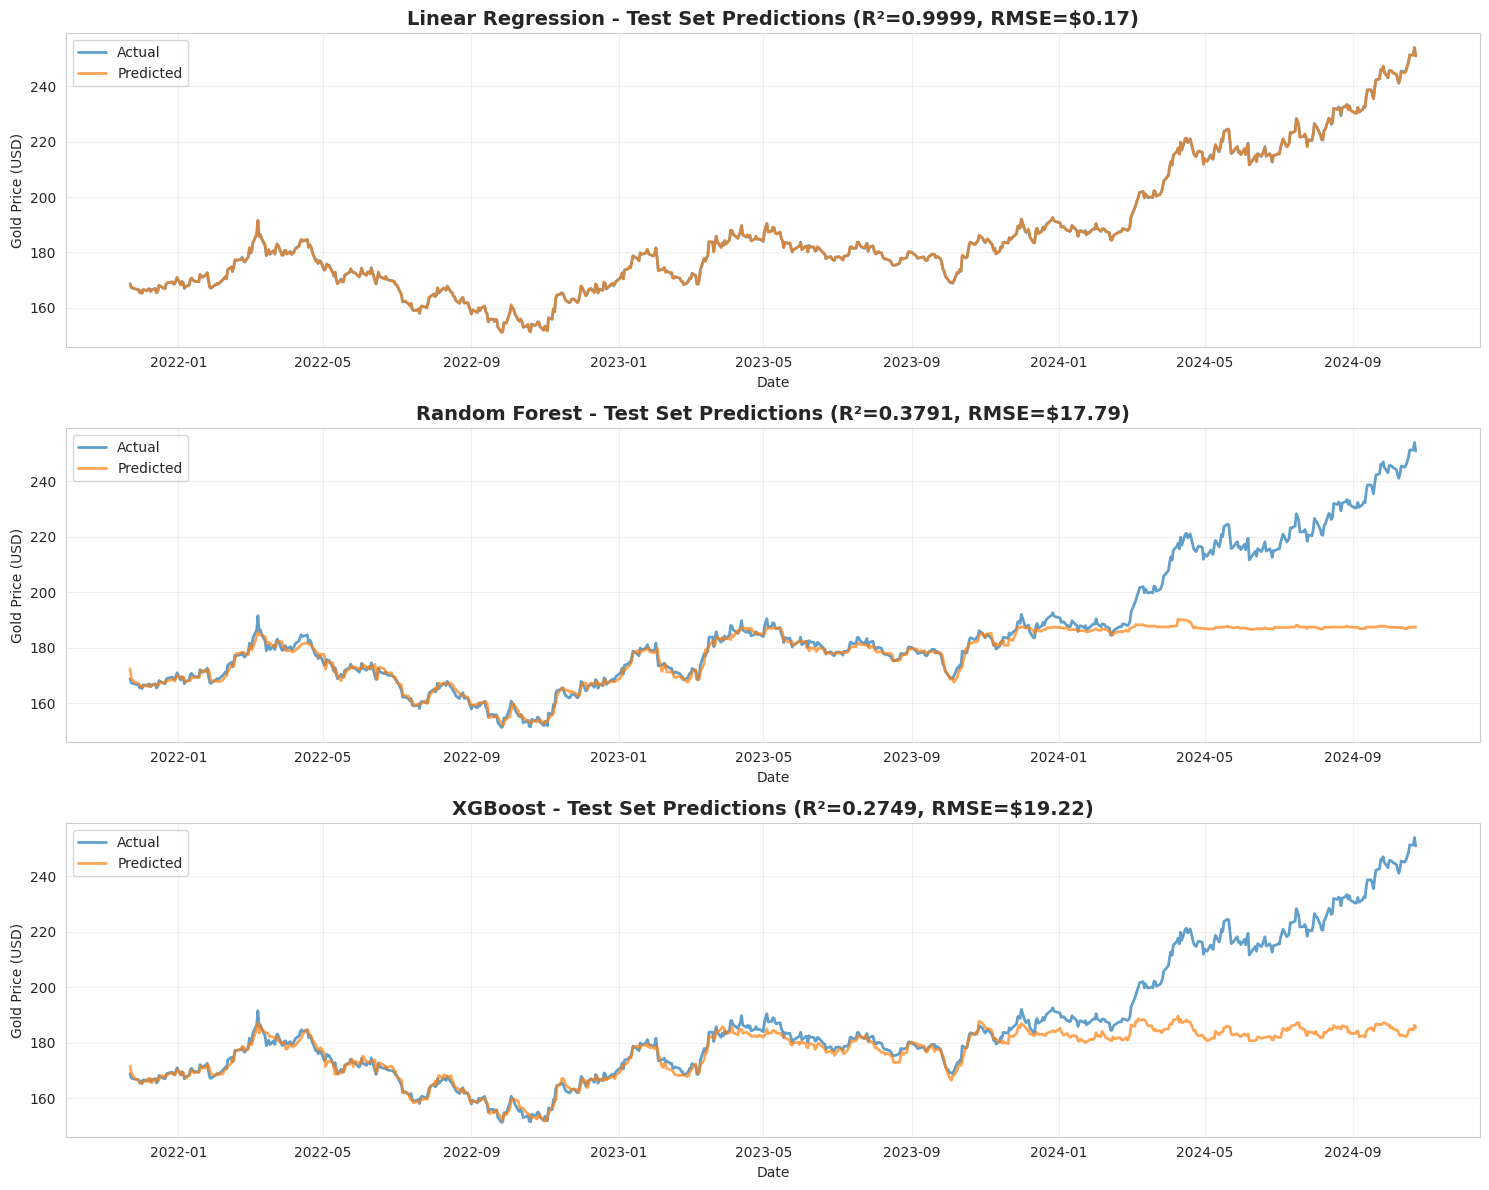

In [25]:
# Plot for best model (assume XGBoost)
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

models_data = [
    ('Linear Regression', y_pred_lr_test, test_r2_lr, test_rmse_lr),
    ('Random Forest', y_pred_rf_test, test_r2_rf, test_rmse_rf),
    ('XGBoost', y_pred_xgb_test, test_r2_xgb, test_rmse_xgb)
]

for idx, (name, predictions, r2, rmse) in enumerate(models_data):
    ax = axes[idx]
    
    # Plot actual vs predicted
    ax.plot(dates_test.values, y_test.values, label='Actual', linewidth=2, alpha=0.7)
    ax.plot(dates_test.values, predictions, label='Predicted', linewidth=2, alpha=0.7)
    
    ax.set_title(f'{name} - Test Set Predictions (R²={r2:.4f}, RMSE=${rmse:.2f})', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Gold Price (USD)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/plots/baseline_predictions_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved prediction comparison plot")
plt.show()

✓ Saved model comparison chart


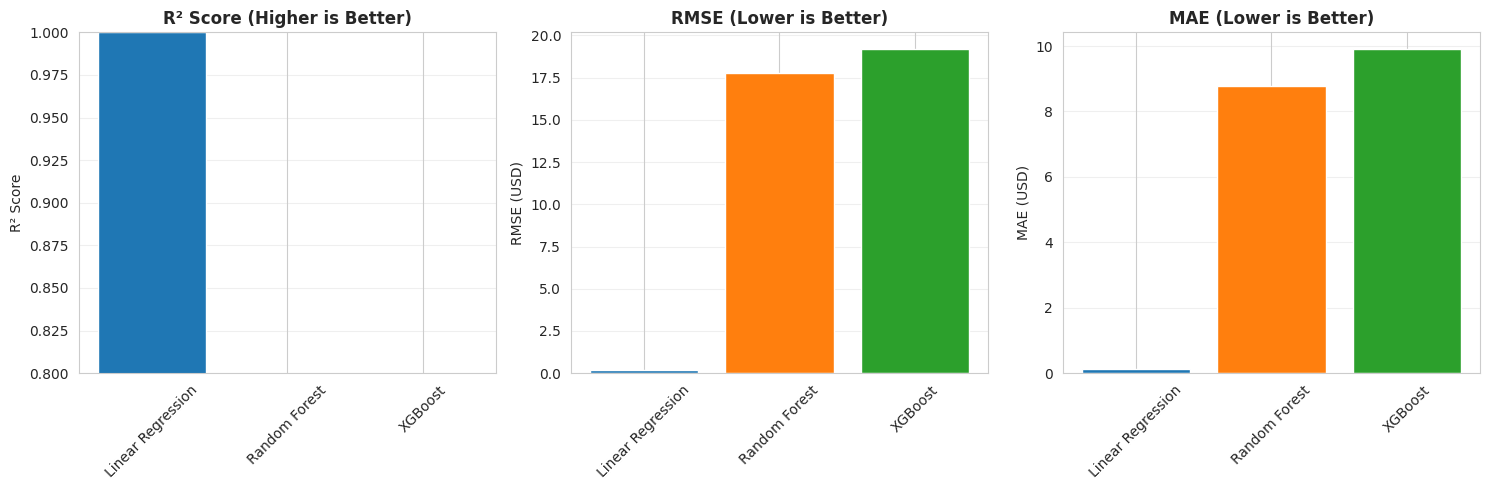

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# R² Score
axes[0].bar(comparison_df['Model'], comparison_df['Test_R2'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title('R² Score (Higher is Better)', fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim([0.8, 1.0])
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# RMSE
axes[1].bar(comparison_df['Model'], comparison_df['Test_RMSE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_title('RMSE (Lower is Better)', fontweight='bold')
axes[1].set_ylabel('RMSE (USD)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

# MAE
axes[2].bar(comparison_df['Model'], comparison_df['Test_MAE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[2].set_title('MAE (Lower is Better)', fontweight='bold')
axes[2].set_ylabel('MAE (USD)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results/plots/baseline_model_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved model comparison chart")
plt.show()

✓ Saved error analysis


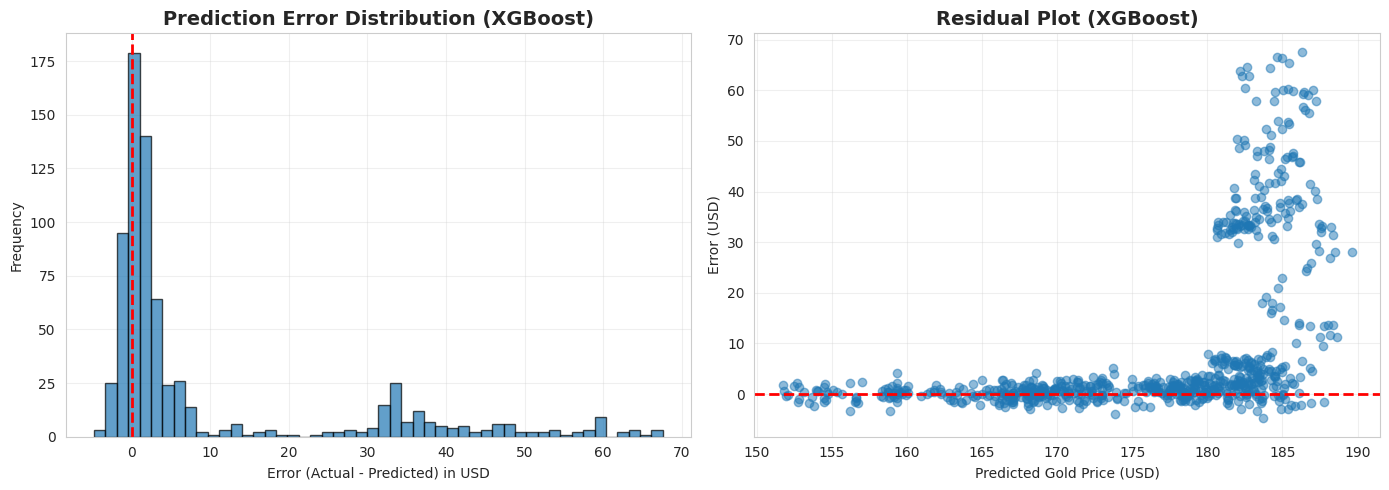

In [27]:
# Calculate errors for best model (XGBoost)
errors_xgb = y_test.values - y_pred_xgb_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of errors
axes[0].hist(errors_xgb, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Prediction Error Distribution (XGBoost)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Error (Actual - Predicted) in USD')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Residual plot
axes[1].scatter(y_pred_xgb_test, errors_xgb, alpha=0.5)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residual Plot (XGBoost)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Predicted Gold Price (USD)')
axes[1].set_ylabel('Error (USD)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/plots/baseline_error_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved error analysis")
plt.show()